Huffman Encoding Node class

In [18]:
import heapq
# -------- Huffman --------
class Node:
    def __init__(self, symbol=None, freq=0):
        self.symbol = symbol
        self.freq = freq
        self.left = None
        self.right = None

    def __lt__(self, other):
        return self.freq < other.freq


def build_tree(freq):
    heap = [Node(sym, f) for sym, f in freq.items()]
    heapq.heapify(heap)

    while len(heap) > 1:
        l = heapq.heappop(heap)
        r = heapq.heappop(heap)

        parent = Node(freq=l.freq + r.freq)
        parent.left = l
        parent.right = r

        heapq.heappush(heap, parent)

    return heap[0]


def generate_codes(node, code="", codes=None):
    if codes is None:
        codes = {}

    if node.symbol is not None:
        codes[node.symbol] = code
        return codes

    generate_codes(node.left, code + "0", codes)
    generate_codes(node.right, code + "1", codes)

    return codes

In [ ]:
import numpy as np
from scipy.fftpack import dct,idct
from collections import Counter

def pad_image(channel):
    H, W = channel.shape
    
    H_pad = (8 - H % 8) % 8
    W_pad = (8 - W % 8) % 8
    
    padded = np.pad(channel, ((0, H_pad), (0, W_pad)), mode='constant')
    
    return padded, (H, W)

def split_blocks(image):
    H, W = image.shape
    
    blocks = image.reshape(H//8, 8, W//8, 8)
    blocks = blocks.transpose(0, 2, 1, 3)
    
    return blocks.reshape(-1, 8, 8)

def merge_blocks(blocks, original_shape):
    H, W = original_shape
    
    H_blocks = H // 8
    W_blocks = W // 8
    
    blocks = blocks.reshape(H_blocks, W_blocks, 8, 8)
    blocks = blocks.transpose(0, 2, 1, 3)
    
    return blocks.reshape(H, W)

def jpeg_dct(blocks):
    # blocks shape: (num_blocks, 8, 8)
    
    dct_blocks = dct(dct(blocks, axis=1, norm='ortho'), axis=2, norm='ortho')
    
    return dct_blocks

def jpeg_idct(dct_blocks):
    # dct_blocks shape: (num_blocks, 8, 8)
    
    idct_blocks = idct(idct(dct_blocks, axis=1, norm='ortho'), axis=2, norm='ortho')
    
    return idct_blocks

def jpeg_quantization(dct_blocks, Q):
    quantized_blocks = np.round(dct_blocks / Q).astype(np.int32)
    
    return quantized_blocks

def jpeg_inverse_quantization(quantized_blocks, Q):
    dct_blocks = quantized_blocks * Q
    
    return dct_blocks

def zigzag_indices(n=8):
    indices = []
    for s in range(2*n - 1):
        if s % 2 == 0:
            for i in range(s + 1):
                j = s - i
                if i < n and j < n:
                    indices.append((i, j))
        else:
            for i in range(s + 1):
                j = s - i
                if j < n and i < n:
                    indices.append((j, i))
    return indices

zigzag_idx = zigzag_indices(8)

def zigzag(block):
    return [block[i, j] for i, j in zigzag_idx]


# -------- RLE --------
def rle_encode(arr):
    if len(arr) == 0:
        return []
    encoded = []
    count = 1
    for i in range(1, len(arr)):
        if arr[i] == arr[i-1]:
            count += 1
        else:
            encoded.append((arr[i-1], count))
            count = 1
    encoded.append((arr[-1], count))
    return encoded

def jpeg_encoding(quantized_blocks):
    # Step 1: Zig-zag
    zigzag_blocks = [zigzag(b) for b in quantized_blocks]

    # Step 2: RLE
    rle_blocks = [rle_encode(b) for b in zigzag_blocks]

    # Step 3: Flatten for Huffman
    flat = []
    for b in rle_blocks:
        flat.extend(b)

    # Step 4: Build Huffman
    freq = Counter(flat)
    root = build_tree(freq)
    codes = generate_codes(root)

    # Step 5: Encode blocks
    encoded_blocks = []
    for b in rle_blocks:
        encoded = "".join(codes[s] for s in b)
        encoded_blocks.append(encoded)

    return encoded_blocks, codes, zigzag_idx

def huffman_decode(bitstring, reverse_codes):
    if not bitstring:
        return []
    decoded = []
    current = ""
    
    for bit in bitstring:
        current += bit
        if current in reverse_codes:
            decoded.append(reverse_codes[current])
            current = ""
    
    return decoded

def rle_decode(rle):
    if not rle:
        return np.zeros(64)
    arr = []
    for val, count in rle:
        arr.extend([val] * count)
    return np.array(arr)

def inverse_zigzag(arr, zigzag_idx):
    block = np.zeros((8, 8))
    
    for k, (i, j) in enumerate(zigzag_idx):
        block[i, j] = arr[k]
    
    return block

def jpeg_decoding(encoded_blocks, codes, zigzag_idx, Q, padded_shape, original_shape):
    # Reverse Huffman codes
    reverse_codes = {v: k for k, v in codes.items()}
    
    reconstructed_blocks = []

    for bitstring in encoded_blocks:
        # Step 1: Huffman decode → RLE symbols
        rle = huffman_decode(bitstring, reverse_codes)

        # Step 2: RLE decode → 1D array
        arr = rle_decode(rle)

        if len(arr) != 64:
            raise ValueError("Block size mismatch")

        # Step 3: Inverse zig-zag → 8x8 block
        block = inverse_zigzag(arr, zigzag_idx)

        # Step 4: Dequantization
        block = jpeg_inverse_quantization(block, Q)

        # Step 5: IDCT
        block = jpeg_idct(block.reshape(1, 8, 8))[0]

        reconstructed_blocks.append(block)

    reconstructed_blocks = np.array(reconstructed_blocks)

    # Step 6: Merge blocks
    reconstructed_image = merge_blocks(reconstructed_blocks, padded_shape)

    # Step 7: Remove padding
    H, W = original_shape
    reconstructed_image = reconstructed_image[:H, :W]

    # Step 8: Shift back
    reconstructed_image = reconstructed_image + 128

    # Step 9: Clip
    reconstructed_image = np.clip(reconstructed_image, 0, 255).astype(np.uint8)

    return reconstructed_image

def jpeg_pipeline(image, Q):
    padded, original_shape = pad_image(image)
    padded_shape = padded.shape

    blocks = split_blocks(padded)

    dct_blocks = jpeg_dct(blocks)

    quantized_blocks = jpeg_quantization(dct_blocks, Q)

    encoded_blocks, codes, zigzag_idx = jpeg_encoding(quantized_blocks)

    reconstructed_image = jpeg_decoding(
        encoded_blocks,
        codes,
        zigzag_idx,
        Q,
        padded_shape,
        original_shape
    )

    return reconstructed_image, encoded_blocks, dct_blocks

In [20]:
from sklearn.metrics import mean_squared_error
from skimage.metrics import peak_signal_noise_ratio

def compute_metrics(original, reconstructed, encoded_blocks):
    # Ensure numpy arrays
    original = original.astype(np.float32)
    reconstructed = reconstructed.astype(np.float32)

    # -------------------- MSE --------------------
    mse = mean_squared_error(original.flatten(), reconstructed.flatten())

    # -------------------- PSNR --------------------
    psnr = peak_signal_noise_ratio(original, reconstructed, data_range=255)

    # -------------------- Compression Ratio --------------------
    H, W = original.shape
    original_bits = H * W * 8

    compressed_bits = sum(len(b) for b in encoded_blocks)

    compression_ratio = original_bits / compressed_bits

    # -------------------- Bits Per Pixel --------------------
    bpp = compressed_bits / (H * W)

    return {
        "MSE": mse,
        "PSNR": psnr,
        "Compression_Ratio": compression_ratio,
        "BPP": bpp
    }

In [21]:
from collections import Counter
import math

def compute_entropy(encoded_blocks):
    bitstring = "".join(encoded_blocks)
    
    freq = Counter(bitstring)
    total = len(bitstring)

    entropy = -sum((c/total) * math.log2(c/total) for c in freq.values())
    return entropy

In [22]:
def compute_energy(dct_blocks):
    # Energy = squared magnitude
    energy = np.abs(dct_blocks) ** 2
    
    # Average across all blocks
    avg_energy = np.mean(energy, axis=0)
    
    return avg_energy

Loading Datasets

Datasets used are Kodak,McM and SIPI

In [23]:
import os
from PIL import Image

# -------------------- Load Images --------------------
def load_images(folder_path):
    images = []
    
    for file in os.listdir(folder_path):
        if file.lower().endswith(('.png', '.tif', '.tiff')):
            path = os.path.join(folder_path, file)
            
            try:
                img = Image.open(path)
                images.append({
                    "image": img,
                    "mode": img.mode,   # 'RGB', 'L', etc.
                    "name": file
                })
            except:
                print(f"Skipping {file}")
    
    return images

# -------------------- Dataset Selection --------------------
datasets = {
    "Kodak": "kodak_dataset",
    "McM": "McM_dataset",
    "SIPI": "sipi_dataset"
}

print("Datasets mapped.")

Datasets mapped.


In [24]:
import numpy as np
import pandas as pd

# -------------------- Standard JPEG Quantization Table (Luminance) --------------------
Q = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68,109,103, 77],
    [24, 35, 55, 64, 81,104,113, 92],
    [49, 64, 78, 87,103,121,120,101],
    [72, 92, 95, 98,112,100,103, 99]
], dtype=np.float32)

factors = [0.2, 0.5, 1, 2, 4, 6, 8, 12]

for dataset_name, path in datasets.items():
    print(f"\n{'='*40}")
    print(f" Processing Dataset: {dataset_name}")
    print(f"{'='*40}")
    images = load_images(path)
    
    results = []
    
    for f in factors:
        Q_scaled = Q * f
    
        for idx, item in enumerate(images):
            img = item["image"]
            mode = item["mode"]
            name = item["name"]
            print(f"[{dataset_name}] Processing {name} with factor {f}... {idx + 1} / {len(images)}")
            
            if mode == "L":
                original = np.array(img).astype(np.float32)
                Y = original - 128
    
                reconstructed, encoded, dct_blocks  = jpeg_pipeline(Y, Q_scaled)
                metrics = compute_metrics(original, reconstructed, encoded)
    
            else:
                img = img.convert("RGB")
                original = np.array(img)
    
                img_ycbcr = img.convert("YCbCr")
                img_np = np.array(img_ycbcr).astype(np.float32)
    
                Y  = img_np[:, :, 0] - 128
                Cb = img_np[:, :, 1] - 128
                Cr = img_np[:, :, 2] - 128
    
                Y_rec, enc_Y, dct_Y = jpeg_pipeline(Y, Q_scaled)
                Cb_rec, enc_Cb, dct_Cb = jpeg_pipeline(Cb, Q_scaled)
                Cr_rec, enc_Cr, dct_Cr = jpeg_pipeline(Cr, Q_scaled)
    
                recon_ycbcr = np.stack([Y_rec, Cb_rec, Cr_rec], axis=2).astype(np.uint8)
                reconstructed_img = Image.fromarray(recon_ycbcr, mode="YCbCr").convert("RGB")
                reconstructed = np.array(reconstructed_img)
    
                encoded = enc_Y + enc_Cb + enc_Cr
    
                metrics = compute_metrics(
                    original.mean(axis=2),
                    reconstructed.mean(axis=2),
                    encoded
                )
    
            entropy = compute_entropy(encoded)
            if f == 1:
                energy_map = compute_energy(dct_Y)
                
            results.append({
                "factor": f,
                "PSNR": metrics["PSNR"],
                "CR": metrics["Compression_Ratio"],
                "BPP": metrics["BPP"],
                "MSE": metrics["MSE"],
                "Entropy": entropy
            })
    
    # Convert results to DataFrame
    df = pd.DataFrame(results)
    
    # Average Metrics
    df_avg = df.groupby("factor").mean(numeric_only=True).reset_index()
    
    print(f"\nAverage metrics for {dataset_name}:")
    print(df_avg)
    
    # Save Results
    file_name = f"{dataset_name}_jpeg_full_results.csv"
    df.to_csv(file_name, index=False)
    
    avg_file_name = f"{dataset_name}_jpeg_avg_results.csv"
    df_avg.to_csv(avg_file_name, index=False)
    
    print(f"Results saved to {file_name} and {avg_file_name}")


 Processing Dataset: Kodak
[Kodak] Processing kodim23.png with factor 0.2... 1 / 24
[Kodak] Processing kodim05.png with factor 0.2... 2 / 24
[Kodak] Processing kodim08.png with factor 0.2... 3 / 24
[Kodak] Processing kodim16.png with factor 0.2... 4 / 24
[Kodak] Processing kodim22.png with factor 0.2... 5 / 24
[Kodak] Processing kodim11.png with factor 0.2... 6 / 24
[Kodak] Processing kodim06.png with factor 0.2... 7 / 24
[Kodak] Processing kodim19.png with factor 0.2... 8 / 24
[Kodak] Processing kodim21.png with factor 0.2... 9 / 24
[Kodak] Processing kodim15.png with factor 0.2... 10 / 24
[Kodak] Processing kodim13.png with factor 0.2... 11 / 24
[Kodak] Processing kodim18.png with factor 0.2... 12 / 24
[Kodak] Processing kodim20.png with factor 0.2... 13 / 24
[Kodak] Processing kodim01.png with factor 0.2... 14 / 24
[Kodak] Processing kodim12.png with factor 0.2... 15 / 24
[Kodak] Processing kodim04.png with factor 0.2... 16 / 24
[Kodak] Processing kodim17.png with factor 0.2... 17 

In [25]:
import os

plot_dir = "plots"
os.makedirs(plot_dir, exist_ok=True)

In [26]:
import pandas as pd

datasets = {
    "1": ("Kodak", "kodak_dataset"),
    "2": ("McM", "McM_dataset"),
    "3": ("SIPI", "sipi_dataset")
}

print("Choose dataset:")
for key, (name, _) in datasets.items():
    print(f"{key}. {name}")

choice = input("Enter choice (1/2/3): ")

if choice in datasets:
    dataset_name, _ = datasets[choice]
    file_name = f"{dataset_name}_jpeg_avg_results.csv"
else:
    print("Invalid choice")


df_avg = pd.read_csv(file_name)

print(df_avg)

Choose dataset:
1. Kodak
2. McM
3. SIPI
Invalid choice
     factor       PSNR         CR       BPP         MSE   Entropy
0       0.2  37.611174   1.861981  4.296500   11.271012  0.996752
1       0.2  36.934507   1.333630  5.998665   13.171331  0.997329
2       0.2  36.655643   1.493778  5.355549   14.044814  0.996556
3       0.2  40.116136   3.076176  2.600632    6.330918  0.997781
4       0.2  36.399835   1.278731  6.256203   14.896934  0.997534
..      ...        ...        ...       ...         ...       ...
611    12.0  30.100938  83.187307  0.096169   63.531120  0.989883
612    12.0  26.549324  88.030559  0.090878  143.928894  0.987822
613    12.0  25.819378  44.555555  0.179551  170.271744  0.971657
614    12.0  21.081624  21.848292  0.366161  506.894958  0.990525
615    12.0  27.746426  45.492847  0.175852  109.254105  0.971098

[616 rows x 6 columns]


In [27]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(df_avg["CR"], df_avg["PSNR"], marker='o')

for i, f in enumerate(df_avg["factor"]):
    plt.text(df_avg["CR"][i], df_avg["PSNR"][i], f"f={f}")

plt.xlabel("Compression Ratio")
plt.ylabel("PSNR")
plt.title(f"{dataset_name} - CR vs PSNR")
plt.grid()

file_path = os.path.join(plot_dir, f"{dataset_name}_cr_vs_psnr.png")
plt.savefig(file_path, dpi=300)
plt.show()
plt.close()

print(f"Saved: {file_path}")

AttributeError: 'RcParams' object has no attribute '_get'

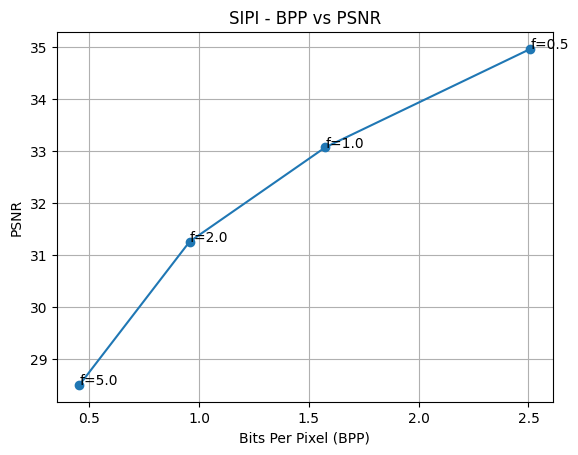

Saved: plots\SIPI_bpp_vs_psnr.png


In [ ]:
plt.figure()

plt.plot(df_avg["BPP"], df_avg["PSNR"], marker='o')

for i, f in enumerate(df_avg["factor"]):
    plt.text(df_avg["BPP"][i], df_avg["PSNR"][i], f"f={f}")

plt.xlabel("Bits Per Pixel (BPP)")
plt.ylabel("PSNR")
plt.title(f"{dataset_name} - BPP vs PSNR")
plt.grid()

file_path = os.path.join(plot_dir, f"{dataset_name}_bpp_vs_psnr.png")
plt.savefig(file_path, dpi=300)
plt.show()
plt.close()

print(f"Saved: {file_path}")

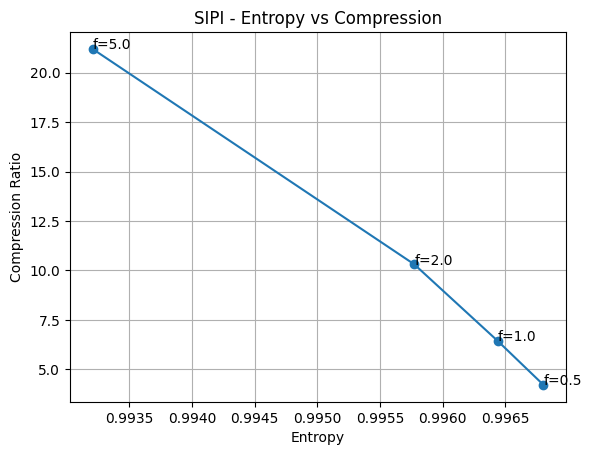

Saved: plots\SIPI_entropy_vs_cr.png


In [ ]:
plt.figure()

plt.plot(df_avg["Entropy"], df_avg["CR"], marker='o')

for i, f in enumerate(df_avg["factor"]):
    plt.text(df_avg["Entropy"][i], df_avg["CR"][i], f"f={f}")

plt.xlabel("Entropy")
plt.ylabel("Compression Ratio")
plt.title(f"{dataset_name} - Entropy vs Compression")
plt.grid()

file_path = os.path.join("plots", f"{dataset_name}_entropy_vs_cr.png")
plt.savefig(file_path, dpi=300)
plt.show()
plt.close()

print(f"Saved: {file_path}")

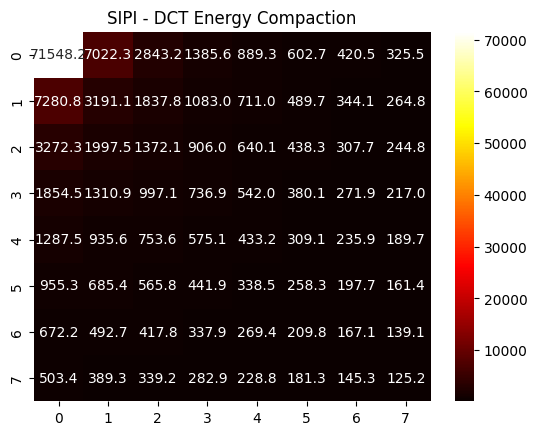

Saved: plots\SIPI_energy_compaction.png


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

plt.figure()

sns.heatmap(
    energy_map,
    cmap="hot",
    annot=True,       
    fmt=".1f"   
)

plt.title(f"{dataset_name} - DCT Energy Compaction")

file_path = os.path.join("plots", f"{dataset_name}_energy_compaction.png")
plt.savefig(file_path, dpi=300)
plt.show()
plt.close()

print(f"Saved: {file_path}")